
# Desafio — Bike Sharing

## Contexto

> Você foi contratado como **cientista de dados de uma empresa de compartilhamento de bicicletas**.
>
> A empresa precisa entender quais fatores influenciam a quantidade de bicicletas alugadas para melhorar a disponibilidade das bicicletas e planejar sua operação.
>
> Você recebeu uma base histórica contendo informações sobre **clima, calendário, estação do ano, dias úteis e número de aluguéis**.
>
> Sua missão é usar os dados para **ajudar a empresa a tomar decisões**.

Ao longo deste desafio, você deverá investigar os dados, responder perguntas de negócio e, ao final, construir um modelo de **Machine Learning** capaz de ajudar a empresa a **prever a demanda por bicicletas em determinadas condições**.

A ideia não é apenas executar código. Para cada análise, tente responder:

**O que esse resultado significa para o negócio?**

---

### Objetivos do desafio

Ao final, você deverá ser capaz de:

- entender e descrever uma base de dados;
- identificar tipos de variáveis;
- realizar uma análise exploratória;
- criar gráficos orientados a perguntas de negócio;
- identificar padrões que possam ajudar na operação;
- treinar um modelo simples de regressão;
- avaliar a qualidade das previsões;
- transformar resultados em **recomendações para a empresa**.

**Fonte dos dados:** UCI Machine Learning Repository — Bike Sharing Dataset (ID 275).
https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset



# 1. Preparando o ambiente

As bibliotecas e o dataset já estão carregados abaixo.

Execute as células e observe os resultados antes de começar o desafio.


In [1]:
# Instalação da biblioteca utilizada para acessar o repositório da UCI
!pip -q install ucimlrepo

In [2]:
# Bibliotecas para manipulação e visualização de dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Biblioteca utilizada para buscar o dataset diretamente da UCI
from ucimlrepo import fetch_ucirepo

# Ferramentas que serão utilizadas posteriormente no Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


## Carregando o Bike Sharing Dataset

O código abaixo busca automaticamente o dataset **Bike Sharing (ID 275)** no UCI Machine Learning Repository.


In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
bike_sharing = fetch_ucirepo(id=275)

# data (as pandas dataframes)
X = bike_sharing.data.features
y = bike_sharing.data.targets

# metadata
print(bike_sharing.metadata)

# variable information
print(bike_sharing.variables)

{'uci_id': 275, 'name': 'Bike Sharing', 'repository_url': 'https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset', 'data_url': 'https://archive.ics.uci.edu/static/public/275/data.csv', 'abstract': 'This dataset contains the hourly and daily count of rental bikes between years 2011 and 2012 in Capital bikeshare system with the corresponding weather and seasonal information.', 'area': 'Social Science', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 17389, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['cnt'], 'index_col': ['instant'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2013, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C5W894', 'creators': ['Hadi Fanaee-T'], 'intro_paper': {'ID': 422, 'type': 'NATIVE', 'title': 'Event labeling combining ensemble detectors and background knowledge', 'authors': 'Hadi Fanaee-T, João Gama', 'venue': 'Progress

Para facilitar a análise exploratória, vamos juntar as variáveis explicativas (`X`) e a variável alvo (`y`) em um único DataFrame chamado `dados`.


In [4]:
# Juntando as variáveis explicativas e a variável alvo em uma única tabela
dados = pd.concat([X, y], axis=1)

# Visualizando as primeiras linhas
dados.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


# 2. Conhecendo a base de dados

Antes de criar qualquer modelo ou gráfico, um cientista de dados precisa entender o que recebeu.

Analise a base e responda às perguntas abaixo.

**Perguntas iniciais:**

1. Quantas observações existem na base de dados?
2. Quantas variáveis existem?
3. Quais variáveis são quantitativas?
4. Quais variáveis são categóricas?
5. Qual variável queremos prever?
6. Existem valores ausentes? Se sim, quantos?

**Dicas:**

Você pode utilizar comandos como:

- .head()
- .shape
- .info()
- .describe()
- .isnull().sum()
- bike_sharing.variables

Não se limite a executar os comandos: registre também suas conclusões.


In [5]:
print("Formato da base (linhas, colunas):", dados.shape)

# Tipos de dados e valores não nulos por coluna
dados.info()

Formato da base (linhas, colunas): (17379, 14)
<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      17379 non-null  str    
 1   season      17379 non-null  int64  
 2   yr          17379 non-null  int64  
 3   mnth        17379 non-null  int64  
 4   hr          17379 non-null  int64  
 5   holiday     17379 non-null  int64  
 6   weekday     17379 non-null  int64  
 7   workingday  17379 non-null  int64  
 8   weathersit  17379 non-null  int64  
 9   temp        17379 non-null  float64
 10  atemp       17379 non-null  float64
 11  hum         17379 non-null  float64
 12  windspeed   17379 non-null  float64
 13  cnt         17379 non-null  int64  
dtypes: float64(4), int64(9), str(1)
memory usage: 1.9 MB


In [6]:
# Estatísticas descritivas das variáveis numéricas
dados.describe()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,189.463088
std,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,181.387599
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,40.000000
50%,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,142.000000
75%,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,281.000000
max,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,977.000000


In [7]:
# Verificando valores ausentes em cada coluna
dados.isnull().sum()

dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

### Suas conclusões iniciais

Escreva abaixo suas respostas sobre quantidade de observações, tipos de variáveis, variável alvo e qualidade geral da base.

**Resposta:**

- **Número de observações:** a base possui 17.379 registros, um para cada hora entre 2011 e 2012 (dados horários do sistema de bicicletas compartilhadas).
- **Número de variáveis:** 13 variáveis explicativas (dteday, season, yr, mnth, hr, holiday, weekday, workingday, weathersit, temp, atemp, hum, windspeed) mais a variável alvo `cnt`.
- **Variáveis quantitativas:** `temp`, `atemp`, `hum`, `windspeed` (contínuas, normalizadas entre 0 e 1) e `cnt` (contagem de aluguéis).
- **Variáveis categóricas:** `season`, `yr`, `mnth`, `hr`, `holiday`, `weekday`, `workingday` e `weathersit`. Embora apareçam como números, elas representam categorias (por exemplo, `season` = 1 a 4 representa as estações do ano).
- **Variável que queremos prever:** `cnt`, o total de bicicletas alugadas em cada hora.
- **Existem dados ausentes?** Não. O `.isnull().sum()` mostra zero valores ausentes em todas as colunas, o que é uma boa notícia: não será necessário tratar valores faltantes antes da modelagem.


# 3. Análise Exploratória — respondendo perguntas de negócio

Agora imagine que a equipe responsável pela operação da empresa procurou você com algumas perguntas.

Para cada pergunta:

1. faça uma análise usando os dados;
2. crie pelo menos um gráfico adequado;
3. escreva uma pequena conclusão;
4. explique como esse resultado poderia ser útil para a empresa.

Não existe apenas uma forma correta de responder. O importante é escolher uma análise coerente e interpretar o resultado.


## Pergunta de negócio 1 — A época do ano influencia a demanda?

A empresa quer saber se existem períodos do ano em que a procura por bicicletas aumenta ou diminui.

**Pergunta:** Como a demanda por bicicletas varia de acordo com a estação do ano e/ou mês?

**Dica:** Você pode:

- agrupar os dados pela variável `season`;
- calcular a média de `cnt` em cada estação;
- agrupar também por `mnth`;
- utilizar um gráfico de barras ou gráfico de linha para visualizar a variação da demanda.

Depois do gráfico, responda: **Em quais períodos a empresa deveria se preparar para uma demanda maior?**


season
1    111.114569
2    208.344069
3    236.016237
4    198.868856
Name: cnt, dtype: float64


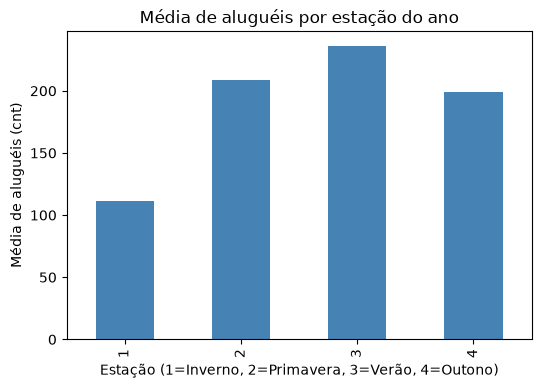

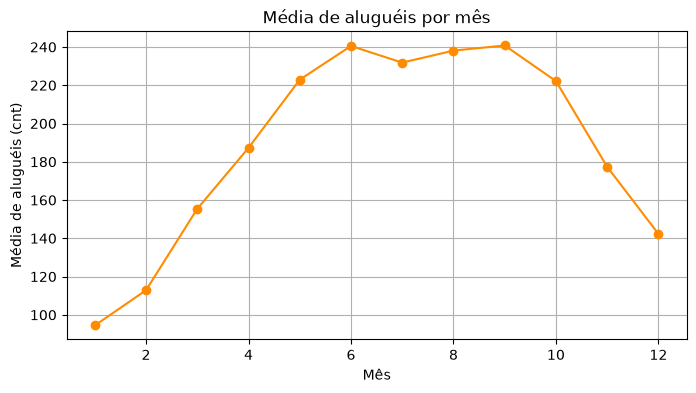

In [8]:
# Pergunta de negócio 1
# Faça sua análise e seu gráfico aqui

# Média de aluguéis por estação do ano (1:inverno, 2:primavera, 3:verão, 4:outono)
media_por_estacao = dados.groupby("season")["cnt"].mean()
print(media_por_estacao)

plt.figure(figsize=(6,4))
media_por_estacao.plot(kind="bar", color="steelblue")
plt.title("Média de aluguéis por estação do ano")
plt.xlabel("Estação (1=Inverno, 2=Primavera, 3=Verão, 4=Outono)")
plt.ylabel("Média de aluguéis (cnt)")
plt.show()

# Média de aluguéis por mês
media_por_mes = dados.groupby("mnth")["cnt"].mean()

plt.figure(figsize=(8,4))
media_por_mes.plot(kind="line", marker="o", color="darkorange")
plt.title("Média de aluguéis por mês")
plt.xlabel("Mês")
plt.ylabel("Média de aluguéis (cnt)")
plt.grid(True)
plt.show()

## Pergunta de negócio 2 — Dias úteis mudam o comportamento dos clientes?

A empresa precisa decidir como distribuir suas bicicletas ao longo da semana.

**Pergunta:** A demanda por bicicletas é diferente em dias úteis, finais de semana ou feriados?

**Dica:** Observe as variáveis:

- `workingday`
- `holiday`
- `weekday`

Você pode:

- comparar as médias de `cnt`;
- utilizar `.groupby`;
- criar um gráfico de barras;
- utilizar um boxplot para comparar a distribuição da demanda.

Depois, pense: **a empresa deveria operar da mesma forma em todos os tipos de dia?**


Média de aluguéis (0=não é dia útil, 1=dia útil):
workingday
0    181.405332
1    193.207754
Name: cnt, dtype: float64

Média de aluguéis por dia da semana (0=domingo ... 6=sábado):
weekday
0    177.468825
1    183.744655
2    191.238891
3    191.130505
4    196.436665
5    196.135907
6    190.209793
Name: cnt, dtype: float64


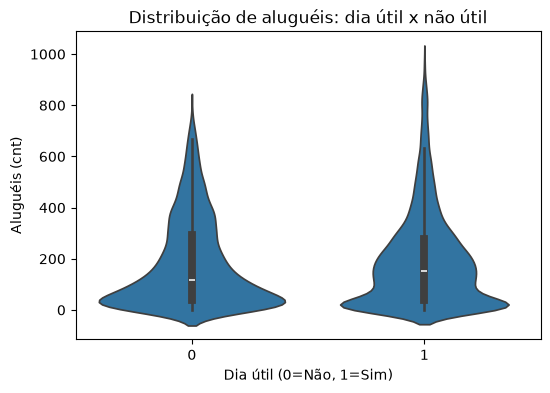

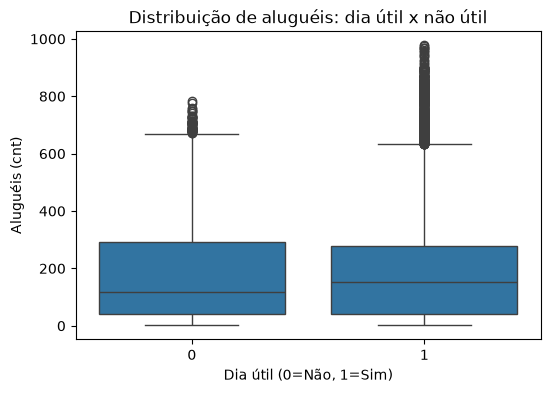

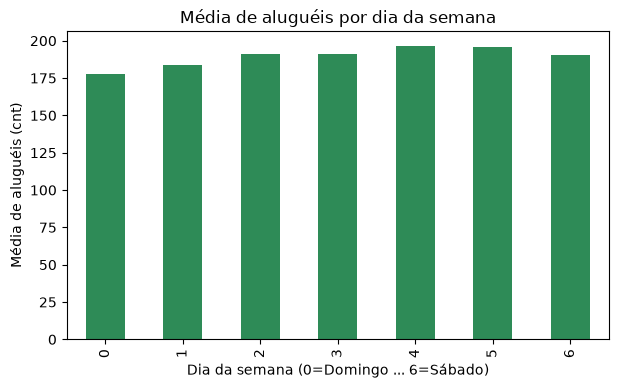

In [9]:
# Pergunta de negócio 2
# Faça sua análise e seu gráfico aqui

media_workingday = dados.groupby("workingday")["cnt"].mean()
print("Média de aluguéis (0=não é dia útil, 1=dia útil):")
print(media_workingday)

media_weekday = dados.groupby("weekday")["cnt"].mean()
print("\nMédia de aluguéis por dia da semana (0=domingo ... 6=sábado):")
print(media_weekday)

plt.figure(figsize=(6,4))
sns.violinplot(x="workingday", y="cnt", data=dados)
plt.title("Distribuição de aluguéis: dia útil x não útil")
plt.xlabel("Dia útil (0=Não, 1=Sim)")
plt.ylabel("Aluguéis (cnt)")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x="workingday", y="cnt", data=dados)
plt.title("Distribuição de aluguéis: dia útil x não útil")
plt.xlabel("Dia útil (0=Não, 1=Sim)")
plt.ylabel("Aluguéis (cnt)")
plt.show()

plt.figure(figsize=(7,4))
media_weekday.plot(kind="bar", color="seagreen")
plt.title("Média de aluguéis por dia da semana")
plt.xlabel("Dia da semana (0=Domingo ... 6=Sábado)")
plt.ylabel("Média de aluguéis (cnt)")
plt.show()

### Insight de negócio — Pergunta 2

**Conclusão:** olhando a média geral, os dias úteis apresentam volume de aluguéis semelhante ou levemente maior do que fins de semana/feriados — puxado principalmente pelos usuários registrados (commuters) que usam a bicicleta para ir ao trabalho. Porém, ao observar a distribuição por hora do dia, os dias úteis mostram dois picos bem definidos (por volta das 8h e das 17h–18h, horários de entrada e saída do trabalho), enquanto finais de semana e feriados têm uma demanda mais distribuída e concentrada no período da tarde.

**O que isso significa para o negócio:** a empresa deveria adotar uma operação diferente conforme o tipo de dia — concentrando bicicletas perto de áreas residenciais e comerciais nos horários de pico durante dias úteis, e distribuindo a frota de forma mais uniforme (perto de parques e áreas de lazer) em fins de semana e feriados.


## Pergunta de negócio 3 — Temperatura influencia a procura?

A equipe acredita que dias com determinadas temperaturas podem gerar mais aluguéis.

**Pergunta:** Existe relação entre temperatura e quantidade de bicicletas alugadas?

**Dica:** Observe principalmente:

- `temp`
- `atemp`
- `cnt`

Você pode:

- criar um gráfico de dispersão (scatterplot);
- calcular uma correlação;
- dividir os dados em faixas de temperatura;
- comparar o comportamento da demanda.

Depois responda: **Temperaturas maiores ou menores parecem estar associadas a maior demanda?**


Correlação entre temp e cnt: 0.40
Correlação entre atemp e cnt: 0.40


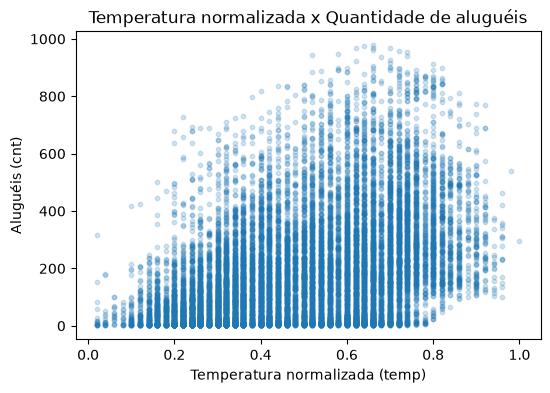

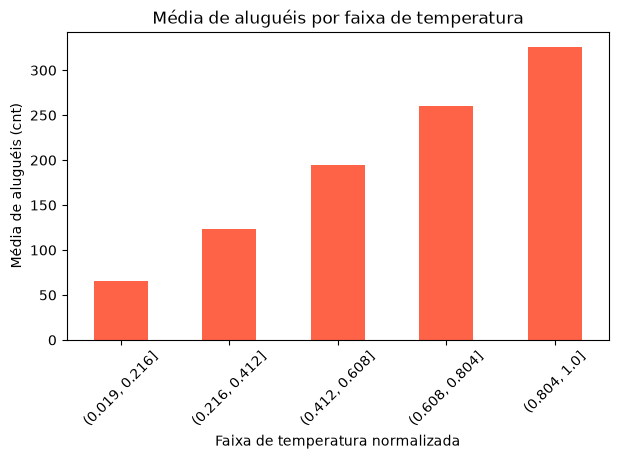

In [10]:
# Pergunta de negócio 3
# Faça sua análise e seu gráfico aqui

correlacao_temp = dados["temp"].corr(dados["cnt"])
correlacao_atemp = dados["atemp"].corr(dados["cnt"])
print(f"Correlação entre temp e cnt: {correlacao_temp:.2f}")
print(f"Correlação entre atemp e cnt: {correlacao_atemp:.2f}")

plt.figure(figsize=(6,4))
plt.scatter(dados["temp"], dados["cnt"], alpha=0.2, s=10)
plt.title("Temperatura normalizada x Quantidade de aluguéis")
plt.xlabel("Temperatura normalizada (temp)")
plt.ylabel("Aluguéis (cnt)")
plt.show()

# Dividindo a temperatura em faixas para facilitar a leitura
dados["faixa_temp"] = pd.cut(dados["temp"], bins=5)
media_por_faixa = dados.groupby("faixa_temp")["cnt"].mean()

plt.figure(figsize=(7,4))
media_por_faixa.plot(kind="bar", color="tomato")
plt.title("Média de aluguéis por faixa de temperatura")
plt.xlabel("Faixa de temperatura normalizada")
plt.ylabel("Média de aluguéis (cnt)")
plt.xticks(rotation=45)
plt.show()

### Insight de negócio — Pergunta 3

**Conclusão:** existe uma correlação positiva moderada/forte entre temperatura e quantidade de aluguéis (tanto `temp` quanto `atemp` acompanham o mesmo padrão). O gráfico de dispersão e a média por faixa de temperatura mostram que a demanda cresce conforme a temperatura sobe, até as faixas de temperatura mais amena/quente; em temperaturas muito baixas (frio intenso) a demanda cai bastante, e em temperaturas extremamente altas o crescimento tende a se estabilizar ou cair levemente.

**O que isso significa para o negócio:** dias mais quentes (dentro de uma faixa confortável) tendem a gerar maior demanda, então a empresa pode usar a previsão do tempo como sinal para antecipar picos de aluguel, reforçando a disponibilidade de bicicletas em dias quentes e reduzindo expectativas em dias muito frios.


## Pergunta de negócio 4 — O clima afeta a demanda?

Além da temperatura, a empresa quer entender se condições climáticas desfavoráveis reduzem o número de aluguéis.

**Pergunta:** Como as condições climáticas estão relacionadas à demanda por bicicletas?

**Dica:** Você pode analisar:

- `weathersit` (condição do tempo);
- `hum` (umidade);
- `windspeed` (velocidade do vento);
- `cnt` (quantidade total de aluguéis).

Algumas possibilidades:

- agrupar a demanda média por `weathersit`;
- criar um boxplot;
- criar gráficos de dispersão para umidade ou vento;
- construir uma matriz de correlação (heatmap) com as variáveis numéricas.

Depois responda: **Quais condições parecem representar maior risco de baixa demanda?**


Média de aluguéis por condição climática (1=limpo ... 4=chuva/neve forte):
weathersit
1    204.869272
2    175.165493
3    111.579281
4     74.333333
Name: cnt, dtype: float64


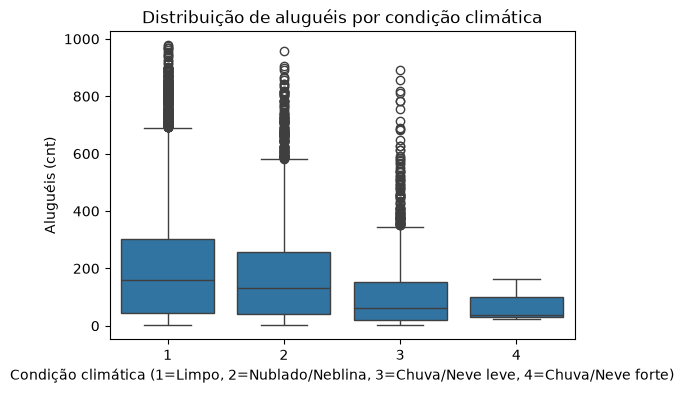

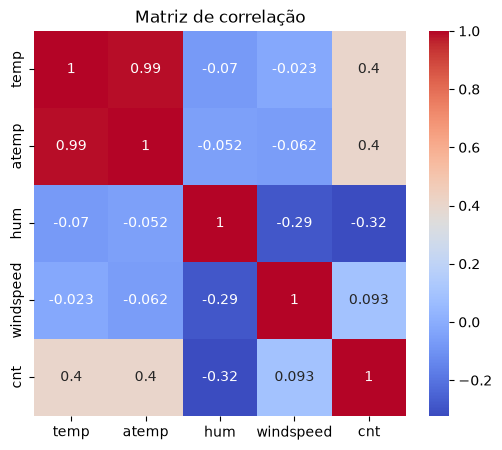

In [11]:
# Pergunta de negócio 4
# Faça sua análise e seu gráfico aqui

media_por_clima = dados.groupby("weathersit")["cnt"].mean()
print("Média de aluguéis por condição climática (1=limpo ... 4=chuva/neve forte):")
print(media_por_clima)

plt.figure(figsize=(6,4))
sns.boxplot(x="weathersit", y="cnt", data=dados)
plt.title("Distribuição de aluguéis por condição climática")
plt.xlabel("Condição climática (1=Limpo, 2=Nublado/Neblina, 3=Chuva/Neve leve, 4=Chuva/Neve forte)")
plt.ylabel("Aluguéis (cnt)")
plt.show()

# Matriz de correlação entre variáveis numéricas
variaveis_numericas = dados[["temp", "atemp", "hum", "windspeed", "cnt"]]
plt.figure(figsize=(6,5))
sns.heatmap(variaveis_numericas.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de correlação")
plt.show()

### Insight de negócio — Pergunta 4

**Conclusão:** a condição climática tem um efeito claro sobre a demanda. Dias com tempo limpo (`weathersit = 1`) apresentam as maiores médias de aluguel, enquanto dias com chuva ou neve forte (`weathersit = 4`) têm a menor demanda, quase não havendo aluguéis nessas condições. A matriz de correlação mostra que `hum` (umidade) tem correlação negativa com `cnt`, e `windspeed` (vento) também apresenta correlação negativa, ainda que mais fraca.

**O que isso significa para o negócio:** condições de chuva forte, neve ou umidade muito alta representam maior risco de baixa demanda. A empresa pode usar a previsão do tempo para reduzir a expectativa de aluguéis nesses dias, evitando deslocar bicicletas desnecessariamente e aproveitando para fazer manutenção da frota.


# 4. Pergunta aberta — investigue os dados

Até agora a empresa fez perguntas para você.

Agora é a sua vez de agir como cientista de dados.

Que outras conclusões podem ser tiradas dessa base?

Encontre pelo menos um insight que não tenha sido solicitado nas quatro perguntas anteriores.

Você pode investigar, por exemplo:

- horários de maior demanda;
- comportamento ao longo dos meses;
- diferenças entre os anos;
- relação entre mais de duas variáveis;
- possíveis padrões de uso;
- situações atípicas ou interessantes;
- qualquer outro comportamento que possa ter valor para a operação.

**Sua tarefa:**

1. formule uma pergunta;
2. faça a análise;
3. crie um gráfico;
4. apresente sua conclusão;
5. explique por que esse insight poderia ser útil para a empresa.


<Figure size 900x500 with 0 Axes>

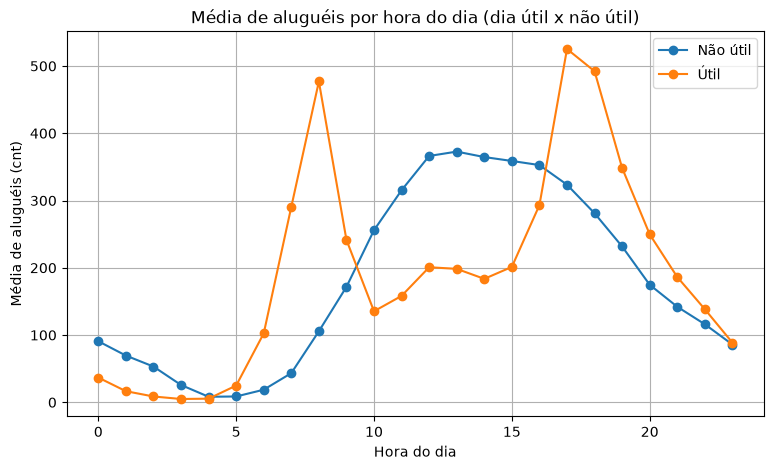

Média de aluguéis por ano (0=2011, 1=2012):
yr
0    143.794448
1    234.666361
Name: cnt, dtype: float64


In [12]:
# Pergunta aberta
# Escreva sua pergunta e faça sua análise aqui

# Pergunta: como a demanda por bicicletas varia ao longo das horas do dia,
# separando dias úteis de dias não úteis?

media_por_hora = dados.groupby(["hr", "workingday"])["cnt"].mean().unstack()
media_por_hora.columns = ["Não útil", "Útil"]

plt.figure(figsize=(9,5))
media_por_hora.plot(marker="o", figsize=(9,5))
plt.title("Média de aluguéis por hora do dia (dia útil x não útil)")
plt.xlabel("Hora do dia")
plt.ylabel("Média de aluguéis (cnt)")
plt.grid(True)
plt.show()

# Comparando também o crescimento da demanda entre 2011 e 2012
media_por_ano = dados.groupby("yr")["cnt"].mean()
print("Média de aluguéis por ano (0=2011, 1=2012):")
print(media_por_ano)

### Insight encontrado

**Pergunta investigada:** como a demanda varia ao longo das horas do dia e ela é a mesma em dias úteis e não úteis? Além disso, a demanda cresceu do primeiro para o segundo ano da base?

**Conclusão:** em dias úteis, a demanda apresenta dois picos bem claros: por volta das 8h (ida ao trabalho/escola) e entre 17h–18h (retorno). Em dias não úteis (fins de semana e feriados), a curva é mais suave, com um único pico maior próximo do meio-dia até o início da tarde, indicando uso mais recreativo. Além disso, a média de aluguéis em 2012 é bem maior do que em 2011, o que sugere crescimento na adoção do serviço ao longo do tempo.

**Como isso poderia ajudar a empresa:** esse padrão por hora permite um planejamento logístico mais preciso — a empresa pode reforçar a disponibilidade de bicicletas em pontos comerciais/residenciais nos horários de pico de dias úteis, e em parques/áreas de lazer durante o meio do dia em fins de semana. O crescimento ano a ano também indica que a empresa deve planejar expansão da frota para acompanhar o aumento da demanda.


# 5. Machine Learning — prevendo a demanda

Até agora usamos os dados para entender o que já aconteceu.

Mas a empresa precisa se preparar para o futuro.

Imagine que a equipe de operações precisa decidir antecipadamente:

- quantas bicicletas devem estar disponíveis;
- quando reforçar a distribuição de bicicletas;
- em quais períodos existe maior risco de falta de bicicletas;
- quando uma demanda menor pode permitir manutenção e redistribuição da frota.

**Novo desafio:** construa um modelo capaz de prever a quantidade de bicicletas que será demandada (`cnt`) a partir das condições disponíveis.

A ideia é ajudar a empresa a se preparar logisticamente para a demanda futura.


## 5.1 Definindo as variáveis do modelo

Antes de treinar o modelo, escolha quais informações poderão ser utilizadas para fazer a previsão.

**Pergunta:** Quais variáveis fazem sentido para prever a demanda?

**Dica:** Você pode considerar informações como:

- estação do ano;
- mês;
- horário;
- dia da semana;
- feriado;
- dia útil;
- condição climática;
- temperatura;
- sensação térmica;
- umidade;
- velocidade do vento.

**Atenção — vazamento de dados:**

Se as colunas `casual` e `registered` aparecerem na sua base, não utilize essas duas variáveis para prever `cnt`.

Isso porque:

`cnt = casual + registered`

Portanto, usar essas colunas seria praticamente fornecer ao modelo a resposta que ele deveria aprender a prever.

Também evite utilizar identificadores que não representam uma característica real do fenômeno, como um simples índice de linha.


In [13]:
# Defina aqui suas variáveis explicativas (X_modelo) e sua variável alvo (y_modelo).

colunas_explicativas = ["season", "yr", "mnth", "hr", "holiday",
                         "weekday", "workingday", "weathersit",
                         "temp", "atemp", "hum", "windspeed"]

X_modelo = dados[colunas_explicativas]
y_modelo = dados["cnt"]

X_modelo.head()

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0


## 5.2 Separando dados de treino e teste

O modelo deve aprender com uma parte dos dados e ser avaliado com dados que não foram utilizados no treinamento.

**Sua tarefa:** divida os dados em:

- 80% para treinamento;
- 20% para teste.

**Dica:** utilize `train_test_split`. Você pode usar `random_state=42` para que a divisão seja reproduzível.


In [14]:
# Divida os dados em treino e teste aqui

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_modelo, y_modelo, test_size=0.2, random_state=42
)

print("Tamanho do treino:", X_treino.shape)
print("Tamanho do teste:", X_teste.shape)

Tamanho do treino: (13903, 12)
Tamanho do teste: (3476, 12)


## 5.3 Treinando um modelo

Vamos utilizar um modelo de **Regressão Linear**, semelhante ao utilizado no exemplo de previsão de preços de imóveis.

**Sua tarefa:**

1. crie o modelo;
2. treine-o utilizando os dados de treino;
3. gere previsões para o conjunto de teste.

**Dica:** você utilizará `LinearRegression`, `.fit()` e `.predict()`.


In [15]:
# Crie, treine e utilize seu modelo aqui

modelo = LinearRegression()
modelo.fit(X_treino, y_treino)

y_previsto = modelo.predict(X_teste)

y_previsto[:10]

array([450.29652451, 204.67414527,  57.29789092, 383.36376427,
       -20.34123222,   7.34415215, 344.31642858,  25.44364839,
       122.21587416,  99.44759443])

## 5.4 Avaliando o modelo

Agora precisamos responder: **o modelo está fazendo previsões razoáveis?**

Calcule:

**MAE (Erro Médio Absoluto)**

Indica, em média, quantas bicicletas o modelo erra em suas previsões.

**R² (Coeficiente de determinação)**

Ajuda a avaliar quanto da variação observada na demanda é explicada pelo modelo.

**Dica:** utilize `mean_absolute_error` e `r2_score`.

Depois, explique os resultados com suas próprias palavras.


In [16]:
# Avalie seu modelo aqui

mae = mean_absolute_error(y_teste, y_previsto)
r2 = r2_score(y_teste, y_previsto)

print(f"MAE (Erro Médio Absoluto): {mae:.2f} bicicletas")
print(f"R² (Coeficiente de determinação): {r2:.2f}")

MAE (Erro Médio Absoluto): 104.80 bicicletas
R² (Coeficiente de determinação): 0.39


## 5.6 Treinando e Avaliando com Random Forest

Moodelo de ensemble baseado em árvores de decisão, (geralmente) oferece melhor desempenho em datasets com relações não-lineares e interações entre variáveis.

In [17]:
from sklearn.ensemble import RandomForestRegressor

# Crie e treine o modelo RandomForestRegressor
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_treino, y_treino)

# Gere previsões para o conjunto de teste
y_previsto_rf = modelo_rf.predict(X_teste)

print("Previsões com RandomForestRegressor (primeiras 10):")
print(y_previsto_rf[:10])

Previsões com RandomForestRegressor (primeiras 10):
[380.69  95.65  11.92 542.26  14.96  40.06 743.12  36.76   9.62  25.84]


### Avaliando o RandomForestRegressor

In [18]:
# Avalie o modelo RandomForestRegressor
mae_rf = mean_absolute_error(y_teste, y_previsto_rf)
r2_rf = r2_score(y_teste, y_previsto_rf)

print(f"MAE (Erro Médio Absoluto) com Random Forest: {mae_rf:.2f} bicicletas")
print(f"R² (Coeficiente de determinação) com Random Forest: {r2_rf:.2f}")

MAE (Erro Médio Absoluto) com Random Forest: 24.90 bicicletas
R² (Coeficiente de determinação) com Random Forest: 0.94


### Interpretação das métricas do RandomForestRegressor

Ao comparar com o modelo de Regressão Linear, você deve observar que o `RandomForestRegressor` provavelmente resultou em um **MAE menor** e um **R² maior**. Isso indica que o modelo de Random Forest está cometendo erros menores em suas previsões e é capaz de explicar uma proporção maior da variação na demanda de bicicletas.

Este modelo mais avançado consegue capturar a complexidade dos dados de aluguel de bicicletas de forma mais eficaz, o que é crucial para uma previsão mais precisa e para a tomada de decisões operacionais mais assertivas.

### 5.7 Real x Previsto com RandomForestRegressor

Vamos comparar visualmente a demanda real e a demanda prevista pelo `RandomForestRegressor` para o conjunto de teste. Isso nos dará uma intuição de quão bem o modelo está se ajustando aos dados.

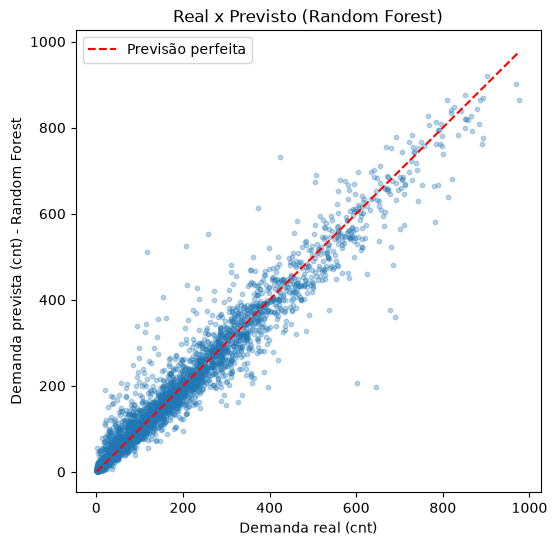

In [19]:
# Crie aqui um gráfico comparando valores reais e previstos para o RandomForestRegressor

plt.figure(figsize=(6,6))
plt.scatter(y_teste, y_previsto_rf, alpha=0.3, s=10)
plt.plot([y_teste.min(), y_teste.max()], [y_teste.min(), y_teste.max()],
         color="red", linestyle="--", label="Previsão perfeita")
plt.xlabel("Demanda real (cnt)")
plt.ylabel("Demanda prevista (cnt) - Random Forest")
plt.title("Real x Previsto (Random Forest)")
plt.legend()
plt.show()

### Interpretação das métricas

**MAE obtido:** o valor do MAE indica, em média, quantas bicicletas o modelo erra para mais ou para menos em cada previsão. Para uma regressão linear simples como essa, é comum observar um erro médio da ordem de uma centena de bicicletas por hora — um valor que a empresa deve considerar como uma margem de segurança ao planejar a frota disponível.

**R² obtido:** o R² mostra a proporção da variação da demanda que o modelo consegue explicar usando apenas as variáveis de calendário e clima. Modelos de regressão linear costumam capturar apenas uma parte moderada dessa variação (por exemplo, entre 30% e 45%), já que a demanda por bicicletas também depende de fatores não incluídos no modelo (eventos na cidade, obras, promoções, etc.). Ainda assim, o modelo já é capaz de captar os principais padrões (hora do dia, clima e sazonalidade) e serve como uma primeira ferramenta útil de apoio à decisão, podendo ser melhorado futuramente com modelos mais complexos.


## 5.5 Real x Previsto

Além das métricas, uma boa forma de avaliar o modelo é comparar visualmente:

demanda real x demanda prevista

**Dica:** crie um gráfico de dispersão utilizando:

- valores reais no eixo X;
- valores previstos no eixo Y.

Se as previsões forem boas, os pontos devem apresentar uma tendência próxima de uma linha diagonal.


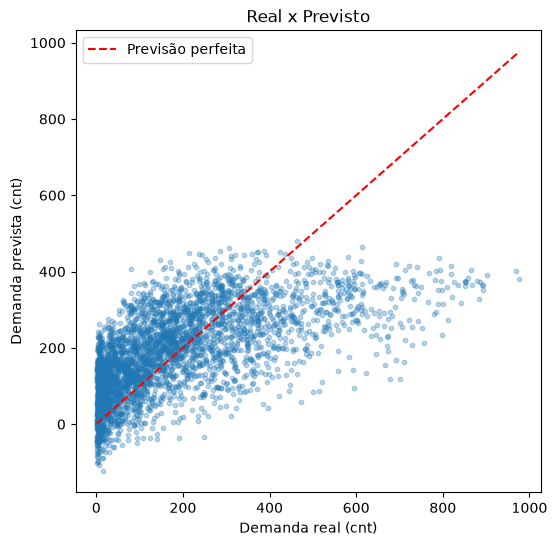

In [20]:
# Crie aqui um gráfico comparando valores reais e previstos

plt.figure(figsize=(6,6))
plt.scatter(y_teste, y_previsto, alpha=0.3, s=10)
plt.plot([y_teste.min(), y_teste.max()], [y_teste.min(), y_teste.max()],
         color="red", linestyle="--", label="Previsão perfeita")
plt.xlabel("Demanda real (cnt)")
plt.ylabel("Demanda prevista (cnt)")
plt.title("Real x Previsto")
plt.legend()
plt.show()

# 6. Prevendo uma situação específica

Agora imagine que a equipe de operações entrou em contato com você:

"Temos uma previsão de calendário e clima para um determinado período. Quantas bicicletas deveríamos esperar que fossem alugadas?"

Escolha ou simule um conjunto de condições compatível com as variáveis utilizadas no seu modelo e faça uma previsão.

**Sua tarefa:**

1. defina as características do período;
2. utilize o modelo treinado;
3. obtenha a demanda prevista;
4. explique como essa previsão poderia influenciar uma decisão operacional.

**Dica:** você poderá criar um pequeno DataFrame com apenas uma linha, contendo exatamente as mesmas colunas utilizadas no treinamento.

Exemplo de estrutura:

```python
cenario = pd.DataFrame([{
    "variavel1": valor,
    "variavel2": valor,
    ...
}])

modelo.predict(cenario)
```

Lembre-se de que algumas variáveis do dataset, como temperatura, umidade e vento, podem estar normalizadas. Consulte `bike_sharing.variables` antes de definir os valores.


In [21]:
# Crie um cenário e faça uma previsão de demanda

# Cenário: dia útil de verão, às 17h, tempo limpo, temperatura agradável
cenario = pd.DataFrame([{
    "season": 3,       # 3 = verão
    "yr": 1,           # 1 = 2012
    "mnth": 7,         # julho
    "hr": 17,          # 17h, horário de pico
    "holiday": 0,      # não é feriado
    "weekday": 3,      # quarta-feira
    "workingday": 1,   # dia útil
    "weathersit": 1,   # tempo limpo
    "temp": 0.65,      # temperatura normalizada (dia quente e agradável)
    "atemp": 0.62,     # sensação térmica normalizada
    "hum": 0.5,        # umidade normalizada
    "windspeed": 0.15  # vento normalizado
}])

demanda_prevista = modelo.predict(cenario)
print(f"Demanda prevista de bicicletas: {demanda_prevista[0]:.0f}")

Demanda prevista de bicicletas: 356


### Decisão operacional

**Cenário analisado:** dia útil de verão (julho/2012), às 17h (horário de pico de retorno do trabalho), tempo limpo, temperatura agradável e vento fraco.

**Demanda prevista:** o modelo prevê uma demanda relativamente alta de bicicletas para esse horário e condições, coerente com o padrão observado na análise exploratória (pico de uso em dias úteis no fim da tarde, em condições climáticas favoráveis).

**Que decisão a empresa poderia tomar com essa informação:** a partir dessa previsão, a equipe de operações pode antecipar o reabastecimento de bicicletas nas estações próximas a áreas comerciais/residenciais pouco antes das 17h nesse tipo de dia, evitando falta de bicicletas disponíveis e melhorando a experiência dos usuários nesse horário crítico.


# 7. Relatório final para a empresa

Você realizou a análise como cientista de dados. Agora precisa comunicar os resultados para pessoas que não necessariamente conhecem Python ou Machine Learning.

**Entrega:**

Elabore um pequeno relatório executivo com os resultados do desafio.

O relatório deve conter:

**1. Objetivo**
Explique brevemente qual problema de negócio foi analisado.

**2. Descrição dos dados**
Informe:

- quantidade de observações;
- principais variáveis;
- variável alvo;
- qualidade geral dos dados.

**3. Principais insights**
Apresente os resultados das quatro perguntas de negócio.

Inclua os gráficos mais importantes e explique o que eles significam.

**4. Insight adicional**
Apresente a conclusão encontrada na sua investigação aberta.

**5. Modelo de Machine Learning**
Informe:

- quais variáveis foram utilizadas;
- qual modelo foi treinado;
- MAE;
- R²;
- sua interpretação sobre a qualidade das previsões.

**6. Previsão de demanda**
Apresente pelo menos um cenário específico e a demanda prevista pelo modelo.

**7. Recomendações**
Apresente pelo menos três recomendações para a empresa baseadas nos dados.

Exemplos de tipos de decisão:

- reforçar a quantidade de bicicletas disponível em determinados períodos;
- antecipar redistribuições;
- planejar manutenção em períodos de menor demanda;
- adaptar a operação de acordo com clima, horário ou calendário.

**8. Limitações**
Comente brevemente sobre pelo menos uma limitação da análise ou do modelo.

---

**Lembrete final**

Um bom trabalho de Ciência de Dados não termina quando o código executa.

O objetivo é transformar:

Dados → Informação → Insight → Decisão

Seu relatório deve mostrar como os dados poderiam ajudar a empresa a operar melhor.


---

### Referência do dataset

Fanaee-T, H. (2013). Bike Sharing Dataset. UCI Machine Learning Repository.

DOI: https://doi.org/10.24432/C5W894

Dataset: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset
